### Cell 1 — Reusable configuration

In [1]:
import xarray as xr
import rioxarray
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
import os
import glob

print("successfully imported libraries")

# ============ CONFIG — only this block changes per index ============
INDEX_NAME = "TXx"      # Folder under indices/: TXx, RX1Day, RX5Day, CDD, WSDI
VAR_NAME = "tasmax"     # Variable in the .nc file: tasmax, rx1dayETCCDI, rx5dayETCCDI, cddETCCDI, wsdiETCCDI
UNITS = "°C"            # °C, mm, or days
# =======================================================================

base_dir = Path("/mnt/wcs-s2-d4/etccdi_extreme_indices/output")
output_dir = Path(f"/mnt/wcs-s2-d4/etccdi_extreme_indices/plots/india/{INDEX_NAME}_emergence")
os.makedirs(output_dir, exist_ok=True)

shapefile_path = "/mnt/wcs-s2-d3/abbas/shapefiles/geoBoundaries-IND-ADM1-all/geoBoundaries-IND-ADM1.shp"
shape = gpd.read_file(shapefile_path).dissolve()

models = ["CSIRO-Mk3L-1-2", "HadGEM2-ES"]
colors = {"rcp45": "#e03030", "g4": "#3a85c8"}
scenarios = ["rcp45", "g4"]

successfully imported libraries


### Cell 2 — Time of Emergence (time series)

diff = rcp45 - g4
CSIRO-Mk3L-1-2: rcp45 - g4, ToE = 2079
diff = rcp45 - g4
HadGEM2-ES: rcp45 - g4, ToE = 2089


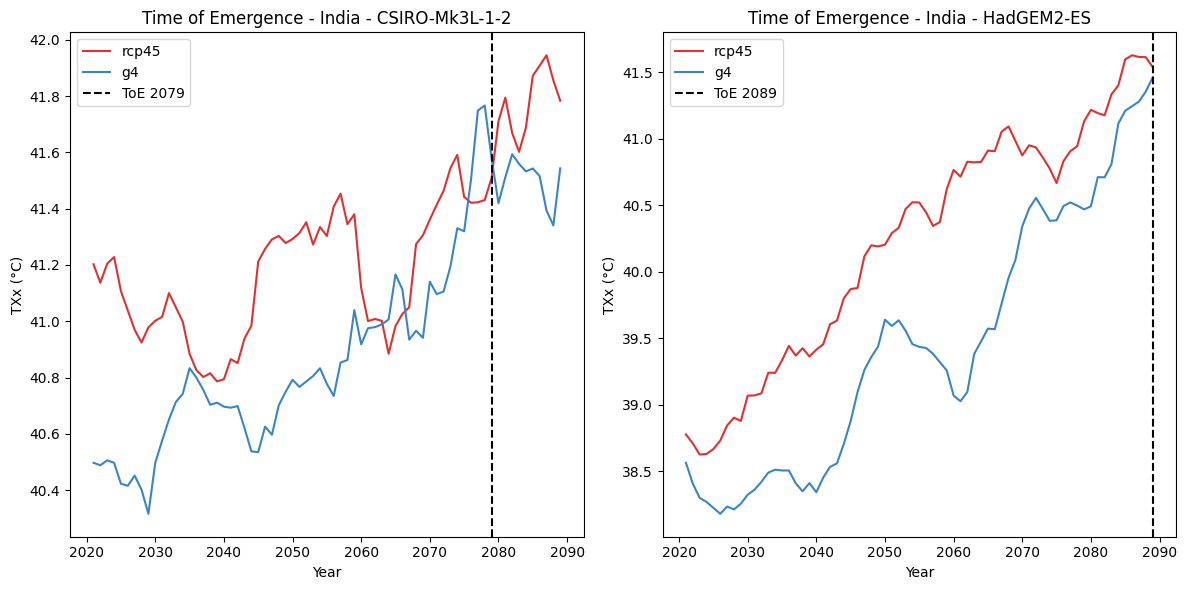

In [2]:
results = {}

for model in models:
    for scenario in scenarios:
        pattern = base_dir / model / "indices" / INDEX_NAME / scenario / f"{INDEX_NAME.lower()}_{model}_historical_{scenario}_*.nc"
        matches = glob.glob(str(pattern))

        if not matches:
            print("No file found for: {model} {scenaio}: {pattern}")
            continue
        file = matches[0]

        time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
        ds = xr.open_dataset(file, decode_times=time_coder)

        da = ds[VAR_NAME].rio.write_crs("EPSG:4326")
        da = da.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
        da = da.rio.clip(shape.geometry, shape.crs)
        # select 2020-2100
        da = da.sel(time=slice("2021", "2089"))
        results[f"{model}_{scenario}"] = da.mean(["lat", "lon"])

# special case where if some models are higher than G6Sulfur while some is lesser
def find_toe(ssps, g6sulfur, years):

    # Decide which difference to use
    if ssps[-1] > g6sulfur[-1]:
        diff = ssps - g6sulfur
        print("diff = rcp45 - g4")
    else:
        diff = g6sulfur - ssps
        print("diff = g4 - rcp45")

    emergence_year_index = 0
    check = True

    for i in range(len(diff)):
        if check and diff[i] > 0:
            emergence_year_index = i
            check = False
        elif diff[i] <= 0:
            check = True

    return years[emergence_year_index - 1], diff

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# axes = axes.ravel()

for ax, model in zip(axes, models):

    ssp = results[f"{model}_{scenarios[0]}"].sel(time=slice("2021", "2089"))
    g6s = results[f"{model}_{scenarios[1]}"].sel(time=slice("2021", "2089"))

    # 10 years running mean (just add these two lines)
    ssp = ssp.rolling(time=10, center=True, min_periods=1).mean()
    g6s = g6s.rolling(time=10, center=True, min_periods=1).mean()

    years = ssp.time.dt.year.values
    toe_year, diff = find_toe(ssp.values, g6s.values, years)

    if ssp.values[-1] > g6s.values[-1]:
        direction = f"{scenarios[0]} - {scenarios[1]}"
    else:
        direction = f"{scenarios[1]} - {scenarios[0]}"

    print(f"{model}: {direction}, ToE = {toe_year}")

    ax.plot(years, ssp, color="#e03030", label=f"{scenarios[0]}")
    ax.plot(years, g6s, color="#3a85c8", label=f"{scenarios[1]}")

    ax.axvline(toe_year, color="black", linestyle="--", label=f"ToE {toe_year}")
    # print(model, "ToE =", toe_year)

    ax.set_title(f"Time of Emergence - India - {model}")
    ax.set_xlabel("Year")
    ax.set_ylabel(f"{INDEX_NAME} ({UNITS})")
    ax.legend()

plt.tight_layout()
# plt.savefig(output_dir / f"ToE_{INDEX_NAME}_10yrs_runmean_{scenarios[0]}-{scenarios[1]}.png", dpi=300)
plt.show()

#### Validation

In [ ]:
for ax, model in zip(axes, models):

    ssp = results[f"{model}_{scenarios[0]}"].sel(time=slice("2021", "2089"))
    g6s = results[f"{model}_{scenarios[1]}"].sel(time=slice("2021", "2089"))

    # same 10-year running mean as the plotting cell
    ssp = ssp.rolling(time=10, center=True, min_periods=1).mean()
    g6s = g6s.rolling(time=10, center=True, min_periods=1).mean()

    years = ssp.time.dt.year.values

    toe_year, diff = find_toe(ssp.values, g6s.values, years)

    print(f"\n{'='*40}")
    print(f"Model: {model}")
    print(f"ToE: {toe_year}")
    print("Difference (running mean):")
    for y, d in zip(years, diff):
        print(f"{y}: {d:.3f}")

### Cell 3 — Time of Emergence (spatial plot)

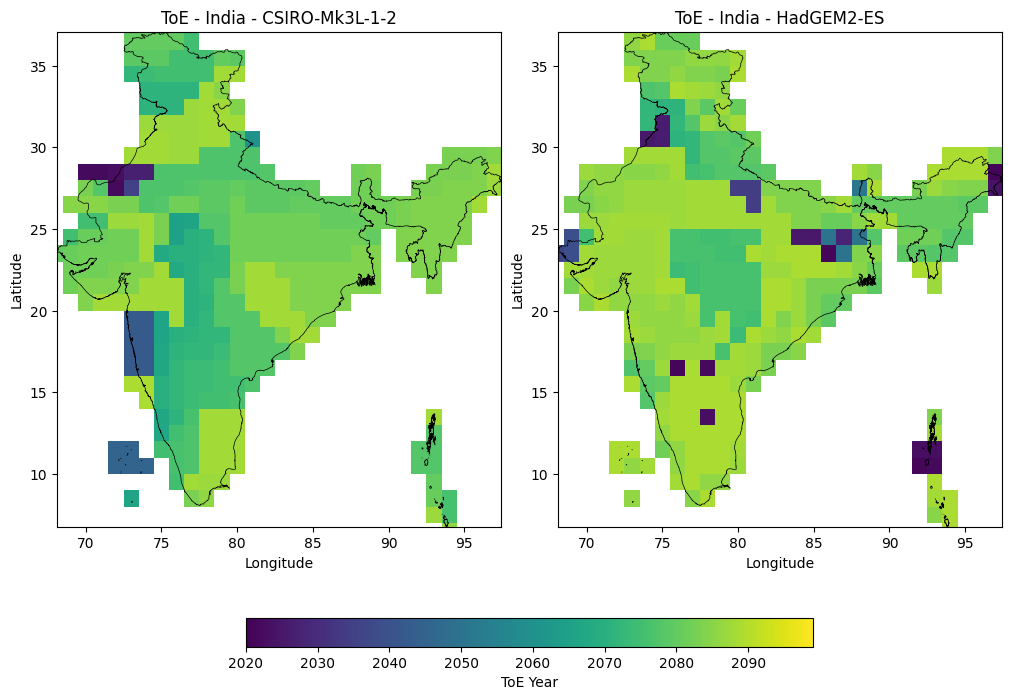

In [3]:
results = {}

for model in models:
    for scenario in scenarios:
        pattern = base_dir / model / "indices" / INDEX_NAME / scenario / f"{INDEX_NAME.lower()}_{model}_historical_{scenario}_*.nc"
        matches = glob.glob(str(pattern))

        if not matches:
            print("file not found for: {model} {scenario}: {pattern}")
            continue
        file = matches[0]

        time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
        ds = xr.open_dataset(file, decode_times=time_coder)

        da = ds[VAR_NAME].rio.write_crs("EPSG:4326")
        da = da.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
        da = da.rio.clip(shape.geometry, shape.crs, all_touched=True)
        da = da.sel(time=slice("2021", "2089"))
        results[f"{model}_{scenario}"] = da   # kept spatial (time, lat, lon)

def find_toe(ssps, g6sulfur, years):

    if ssps[-1] > g6sulfur[-1]:
        diff = ssps - g6sulfur
    else:
        diff = g6sulfur - ssps

    emergence_year_index = 0
    check = True

    for i in range(len(diff)):
        if check and diff[i] > 0:
            emergence_year_index = i
            check = False
        elif diff[i] <= 0:
            check = True

    return years[emergence_year_index - 1]

fig, axes = plt.subplots(1, 2, figsize=(10, 10), constrained_layout=True)
# axes = axes.ravel()

vmin, vmax = 2020, 2099
minx, miny, maxx, maxy = shape.total_bounds

for ax, model in zip(axes, models):

    ssp = results[f"{model}_{scenarios[0]}"].sel(time=slice("2021", "2089"))
    g6s = results[f"{model}_{scenarios[1]}"].sel(time=slice("2021", "2089"))

    ssp = ssp.rolling(time=10, center=True, min_periods=1).mean()
    g6s = g6s.rolling(time=10, center=True, min_periods=1).mean()

    years = ssp.time.dt.year.values

    toe_map = xr.apply_ufunc(
        find_toe, ssp, g6s,
        input_core_dims=[["time"], ["time"]],
        vectorize=True,
        kwargs={"years": years},
    )

    # mask out grid cells that were NaN (outside India / no data) so they don't fall through to vmax
    toe_map = toe_map.where(~np.isnan(ssp.isel(time=0)))

    im = ax.pcolormesh(toe_map.lon, toe_map.lat, toe_map.values, cmap="viridis", vmin=vmin, vmax=vmax)
    shape.boundary.plot(ax=ax, color="black", linewidth=0.5)

    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_title(f"ToE - India - {model}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

fig.colorbar(im, ax=axes.tolist(), orientation="horizontal", label="ToE Year", shrink=0.6, pad=0.05)

# plt.savefig(output_dir / f"ToE_{INDEX_NAME}_map_10yrs_runmean_{scenarios[0]}-{scenarios[1]}.png", dpi=300)
plt.show()

### Cell 4 — Time of Emergence (spatial plot with colors)

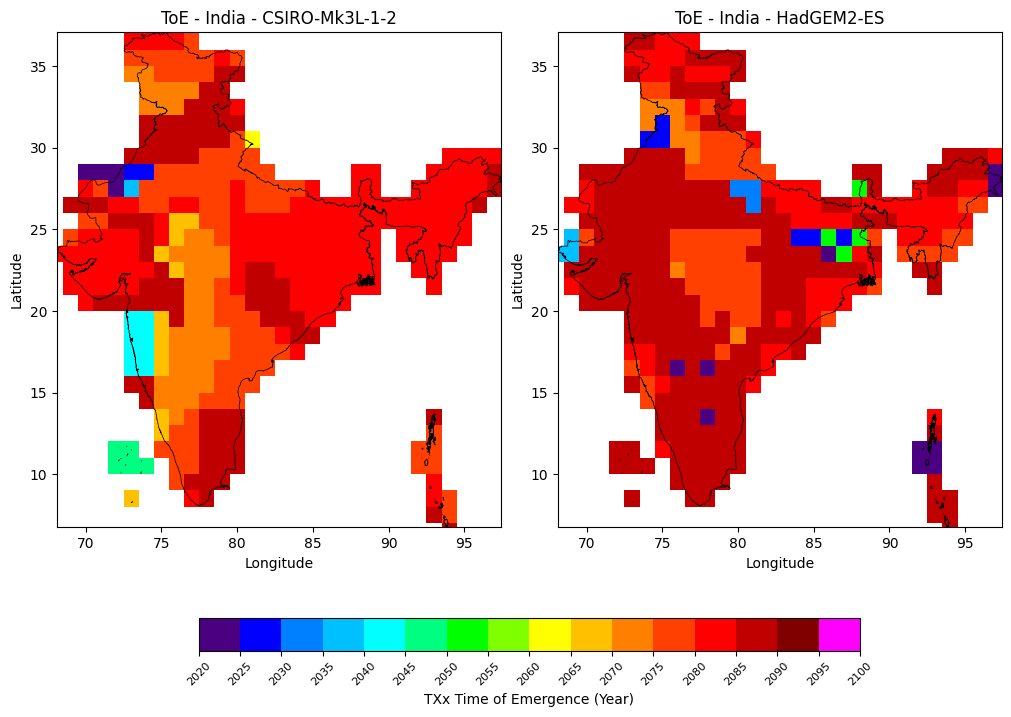

In [ ]:
# Custom scientific sequential palette for ToE (16 steps) \u2014 colors unchanged from original

toe_colors = [
    "#4A0080", "#0000FF", "#007FFF", "#00C0FF", "#00FFFF", "#00FF80",
    "#00FF00", "#80FF00", "#FFFF00", "#FFC000", "#FF8000", "#FF4000",
    "#FF0000", "#C00000", "#800000", "#FF00FF"
]

# Set up the custom colormap structure
cmap = mcolors.ListedColormap(toe_colors)
bounds = np.arange(2020, 2101, 5)  # Creates dividers at 2020, 2025, 2030... 2100
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, axes = plt.subplots(1, 2, figsize=(10, 10), constrained_layout=True)
# axes = axes.ravel()

minx, miny, maxx, maxy = shape.total_bounds

for ax, model in zip(axes, models):

    ssp = results[f"{model}_{scenarios[0]}"].sel(time=slice("2021", "2089"))
    g6s = results[f"{model}_{scenarios[1]}"].sel(time=slice("2021", "2089"))

    ssp = ssp.rolling(time=10, center=True, min_periods=1).mean()
    g6s = g6s.rolling(time=10, center=True, min_periods=1).mean()

    years = ssp.time.dt.year.values

    toe_map = xr.apply_ufunc(
        find_toe, ssp, g6s,
        input_core_dims=[["time"], ["time"]],
        vectorize=True,
        kwargs={"years": years},
    )

    # Clean out non-land / non-India data pixels
    toe_map = toe_map.where(~np.isnan(ssp.isel(time=0)))

    # Apply the sequential mapping
    im = ax.pcolormesh(toe_map.lon, toe_map.lat, toe_map.values, cmap=cmap, norm=norm)
    shape.boundary.plot(ax=ax, color="black", linewidth=0.5)

    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_title(f"ToE - India - {model}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

# Create a clean, block-segmented colorbar aligned beneath the maps
cbar = fig.colorbar(
    im,
    ax=axes.tolist(),
    orientation="horizontal",
    label=f"{INDEX_NAME} Time of Emergence (Year)",
    shrink=0.7,
    pad=0.05,
    boundaries=bounds,
    ticks=bounds
)

# Angle labels so the 5-year text boundaries read clearly
cbar.ax.set_xticklabels(bounds, rotation=45, fontsize=8)

# plt.savefig(output_dir / f"ToE_{INDEX_NAME}_map_10yrs_runmean_{scenarios[0]}-{scenarios[1]}.png", dpi=300)
plt.show()